# Employee Attrition Analysis – ABC Manufacturing Ltd
### AnalystLab Africa – Data Science Internship Programme
**Week 1: Business Understanding & Data Exploration**

Dataset: IBM HR Analytics – Employee Attrition & Performance (1470 employees, 35 variables)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Part 2 – Data Loading & Inspection

In [23]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [24]:
print("Shape:", df.shape)
df.info()

Shape: (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 no

**Missing values check:**

In [25]:
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else print("No missing values found in the dataset.")

No missing values found in the dataset.


**Duplicate rows check:**

In [26]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Descriptive statistics (numeric columns):**

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


**Dataset Inspection Summary:**
- 1470 employee records, 35 columns, no missing values, no duplicate rows.
- Some columns are constant across all rows (`EmployeeCount`, `StandardHours`, `Over18`) and add no analytical value — candidates for removal before modelling.
- Target variable: `Attrition` (Yes/No).


## Part 3 – Initial Data Exploration

### Bar Chart 1: Attrition Count by Department

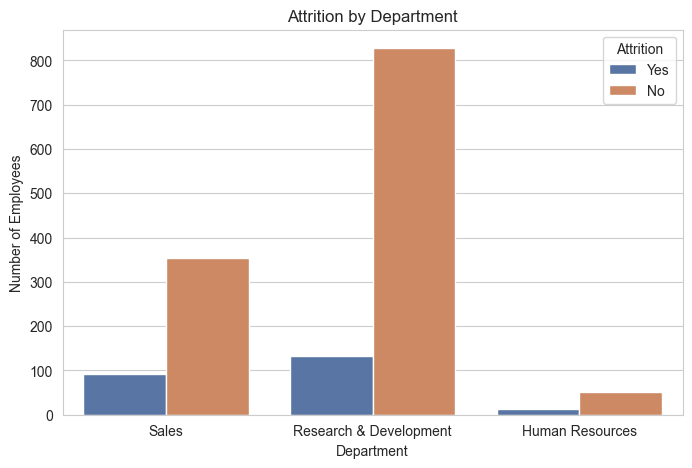

In [28]:
plt.figure()
sns.countplot(data=df, x="Department", hue="Attrition", palette=["#4C72B0", "#DD8452"])
plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.savefig("../visuals/attrition_by_department.png", bbox_inches="tight")
plt.show()

**Interpretation:** Research & Development has the largest workforce and the highest absolute number of departures, but as a proportion of headcount, Sales shows a noticeably higher attrition rate relative to its size.

### Bar Chart 2: Attrition Count by Job Role

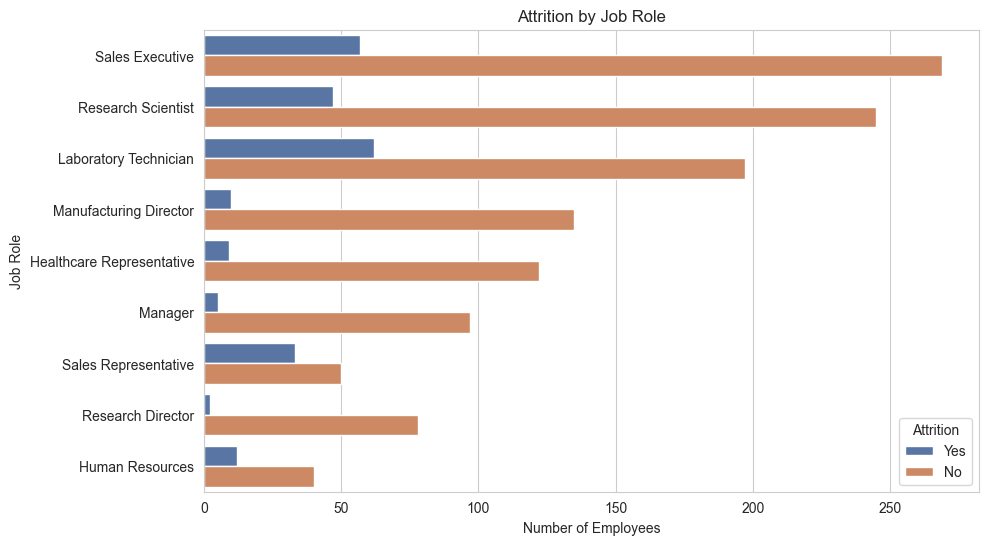

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="JobRole", hue="Attrition", palette=["#4C72B0", "#DD8452"],
              order=df["JobRole"].value_counts().index)
plt.title("Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.savefig("../visuals/attrition_by_jobrole.png", bbox_inches="tight")
plt.show()

**Interpretation:** Sales Representatives and Laboratory Technicians show the highest relative attrition among job roles, suggesting entry-level, high-pressure or lower-tenure positions are more prone to turnover.

### Bar Chart 3: Attrition Count by OverTime

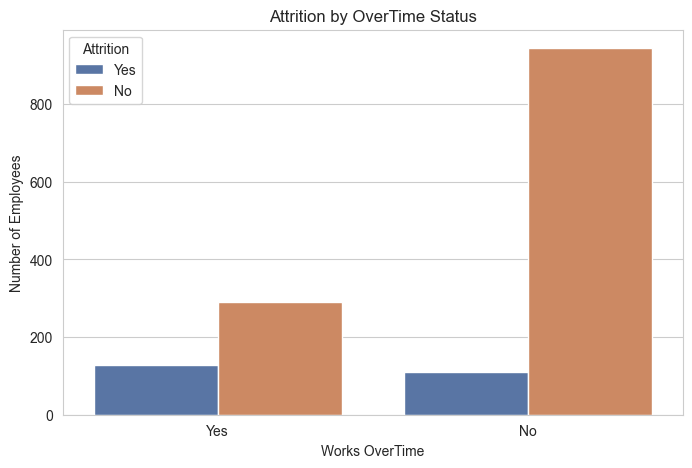

In [30]:
plt.figure()
sns.countplot(data=df, x="OverTime", hue="Attrition", palette=["#4C72B0", "#DD8452"])
plt.title("Attrition by OverTime Status")
plt.xlabel("Works OverTime")
plt.ylabel("Number of Employees")
plt.savefig("../visuals/attrition_by_overtime.png", bbox_inches="tight")
plt.show()

**Interpretation:** Employees who work overtime leave at a much higher rate than those who do not, making `OverTime` one of the strongest visible attrition signals in the dataset.

### Histogram 1: Age Distribution

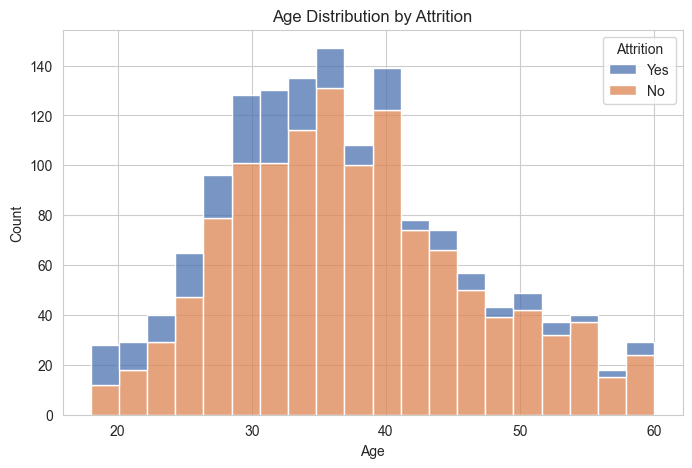

In [31]:
plt.figure()
sns.histplot(data=df, x="Age", hue="Attrition", multiple="stack", bins=20, palette=["#4C72B0", "#DD8452"])
plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("../visuals/age_distribution.png", bbox_inches="tight")
plt.show()

**Interpretation:** The workforce is concentrated between 28 and 40 years old. Attrition is proportionally higher among younger employees (under ~30), tapering off with age.

### Histogram 2: Monthly Income Distribution

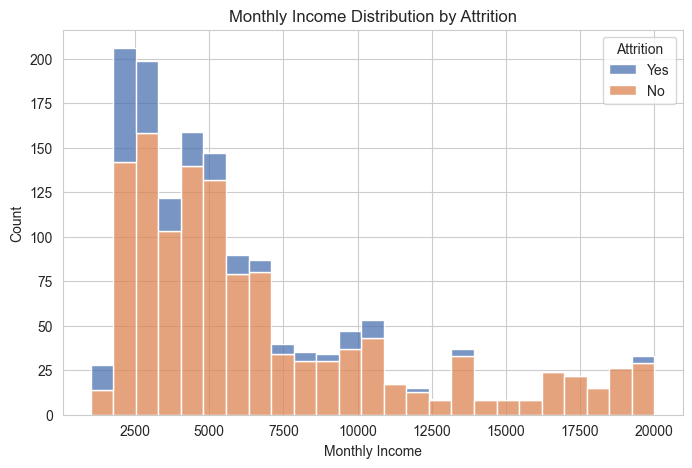

In [32]:
plt.figure()
sns.histplot(data=df, x="MonthlyIncome", hue="Attrition", multiple="stack", bins=25, palette=["#4C72B0", "#DD8452"])
plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.savefig("../visuals/income_distribution.png", bbox_inches="tight")
plt.show()

**Interpretation:** Income is heavily right-skewed — most employees earn under 7,000, with attrition concentrated at the lower end of the income distribution.

### Boxplot 1: Monthly Income by Attrition

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_12708\4053660836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette=["#4C72B0", "#DD8452"])


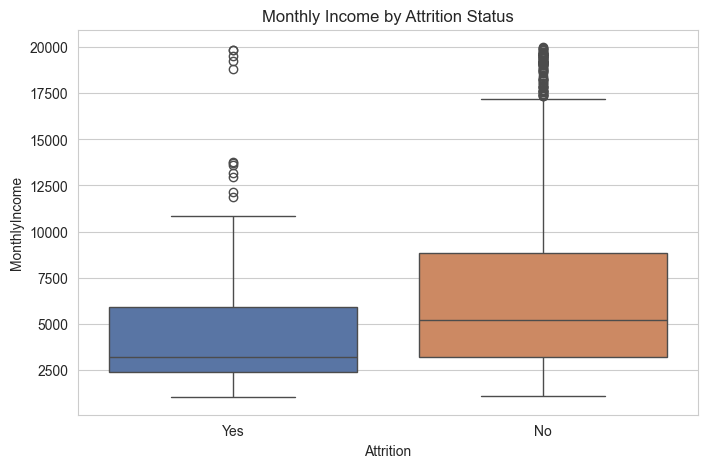

In [33]:
plt.figure()
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", palette=["#4C72B0", "#DD8452"])
plt.title("Monthly Income by Attrition Status")
plt.savefig("../visuals/boxplot_income_attrition.png", bbox_inches="tight")
plt.show()

**Interpretation:** Employees who left have a noticeably lower median monthly income than those who stayed, supporting income as a meaningful retention factor.

### Boxplot 2: Age by Attrition

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_12708\978412782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="Age", palette=["#4C72B0", "#DD8452"])


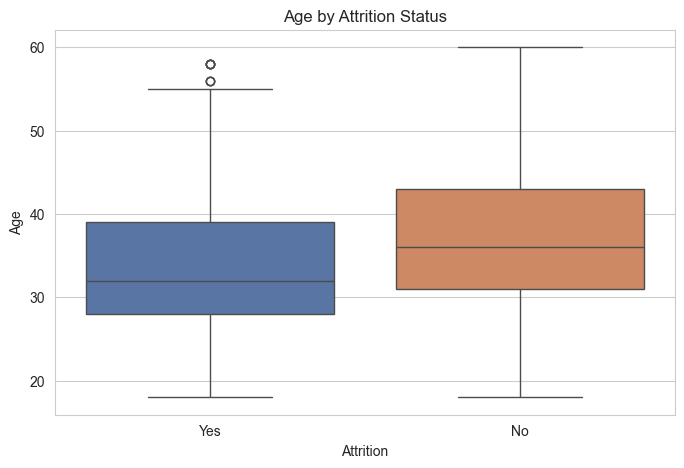

In [34]:
plt.figure()
sns.boxplot(data=df, x="Attrition", y="Age", palette=["#4C72B0", "#DD8452"])
plt.title("Age by Attrition Status")
plt.savefig("../visuals/boxplot_age_attrition.png", bbox_inches="tight")
plt.show()

**Interpretation:** Employees who left tend to be younger on average (lower median age) than those who stayed, reinforcing age as a relevant attrition driver.

### Pie Chart: Overall Attrition Proportion

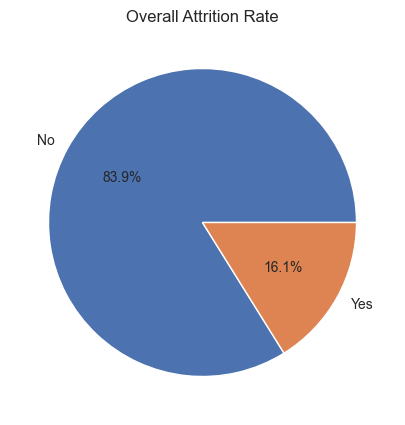

In [35]:
plt.figure()
df["Attrition"].value_counts().plot.pie(
    autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"], ylabel=""
)
plt.title("Overall Attrition Rate")
plt.savefig("../visuals/attrition_pie.png", bbox_inches="tight")
plt.show()

**Interpretation:** Roughly 16% of employees in the dataset have left the company — a meaningful minority that justifies deeper investigation and, eventually, predictive modelling.

## Part 4 – Initial Business Insights

**Five workforce observations:**
1. The workforce is relatively young, with the majority of employees between 28 and 40 years old.
2. Research & Development is the largest department, followed by Sales and Human Resources.
3. Most employees earn under 7,000/month, with a long tail of higher earners in senior roles.
4. Sales Representatives and Laboratory Technicians are among the most populous entry-level roles.
5. Only a minority of employees work overtime, but this group shows disproportionately high attrition.

**Five possible factors contributing to attrition:**
1. **OverTime** — employees working overtime leave at a substantially higher rate.
2. **Monthly Income** — lower earners are overrepresented among leavers.
3. **Age** — younger employees are more likely to leave than older, more established staff.
4. **Job Role** — certain roles (e.g. Sales Representative, Laboratory Technician) show higher turnover.
5. **Department** — Sales shows a higher attrition rate relative to its size compared to other departments.


## Part 7 – Variables Likely Important for Predictive Modelling

Based on the exploration above, the following variables appear most predictive of attrition and
should be prioritised in future modelling work: `OverTime`, `MonthlyIncome`, `Age`, `JobRole`,
`Department`, `YearsAtCompany`, `JobSatisfaction`, and `DistanceFromHome`.
